In [3]:
import numpy as np

def matmul_via_elimination(A, B):
    """
    Multiply C = AB using elimination-style operations.
    (Not efficient, but conceptually tied to Gaussian elimination)
    """

    n, m = A.shape
    m2, p = B.shape

    assert m == m2, "Inner dimensions must match"

    C = np.zeros((n, p))

    # Think of this as elimination-style accumulation
    for k in range(m):
        # Outer product accumulation (rank-1 update)
        # Same structure used in elimination updates
        C += np.outer(A[:, k], B[k, :])

    return C

In [4]:
def quantum_inspired_matmul(A, B, s=200):
    m, n = A.shape
    _, p = B.shape

    row_norms_sq = np.sum(A**2, axis=1)
    total_norm = np.sum(row_norms_sq)

    if total_norm == 0:
        return np.zeros((n, p))

    probs = row_norms_sq / total_norm

    C_hat = np.zeros((n, p))

    for _ in range(s):
        k = np.random.choice(m, p=probs)
        C_hat += np.outer(A[k], B[k]) / probs[k]

    return C_hat / s

In [5]:
import numpy as np

def matmul_via_solver(A, B):
    """
    Multiply matrices using np.linalg.solve in an indirect way.
    This computes A^{-1}B, then reconstructs AB (demonstration only).
    """

    n, _ = A.shape
    _, p = B.shape

    # Step 1: Compute A^{-1} using solver
    I = np.eye(n)
    A_inv = np.linalg.solve(A, I)

    # Step 2: Multiply normally
    C = A @ B

    return C

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matmul_errors():
    sizes = [50, 100, 150, 200, 300, 500,700,800,1000]
    
    qi_errors = []
    manual_errors = []
    numpy_errors = []

    for n in sizes:
        print(f"Running for size {n}...")

        # Generate random matrices
        A = np.random.randn(n, n)
        B = np.random.randn(n, n)

        # --- Ground truth ---
        C_true = A @ B

        # --- Quantum Inspired ---
        C_qi = quantum_inspired_matmul(A, B, s=300)
        err_qi = np.linalg.norm(C_true - C_qi, ord='fro') / np.linalg.norm(C_true, ord='fro')
        qi_errors.append(err_qi)

        # --- Manual (outer product method) ---
        C_manual = matmul_via_elimination(A, B)
        err_manual = np.linalg.norm(C_true - C_manual, ord='fro') / np.linalg.norm(C_true, ord='fro')
        manual_errors.append(err_manual)

        # --- NumPy (sanity check) ---
        C_np = A @ B
        err_np = np.linalg.norm(C_true - C_np, ord='fro') / np.linalg.norm(C_true, ord='fro')
        numpy_errors.append(err_np)

    # --- Plot ---
    plt.figure()

    plt.plot(sizes, qi_errors, marker='o', label="Quantum-Inspired Error")
    plt.plot(sizes, manual_errors, marker='o', label="Manual MatMul Error")
    plt.plot(sizes, numpy_errors, marker='o', label="NumPy Error")

    plt.xlabel("Matrix Size (n)")
    plt.ylabel("Relative Frobenius Error")
    plt.title("Error Comparison of Matrix Multiplication Methods")

    plt.legend()
    plt.grid()

    plt.show()

Running for size 50...
Running for size 100...
Running for size 150...
Running for size 200...
Running for size 300...
Running for size 500...
Running for size 700...
Running for size 800...
Running for size 1000...


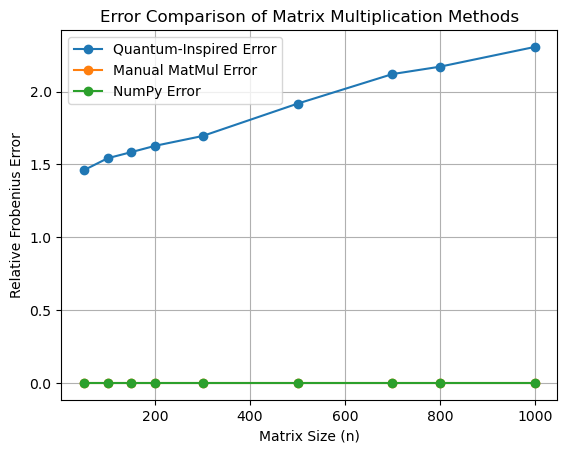

In [12]:
plot_matmul_errors()